In [1]:
from supermarket import Grid
from shopping_list import ShoppingList
import distance

grid = Grid("grid_eng.txt")
shopping_list = ShoppingList.load_from_file("Long_shopping_list.txt")
J_product_category, P_product_category, product_type_indizes = distance.compute_optimal_trajectories(grid, (5,4), (5,0))
J_product, P_product = distance.create_product_cost_path_matrix(shopping_list, J_product_category, P_product_category, product_type_indizes)

# Introducing hardness

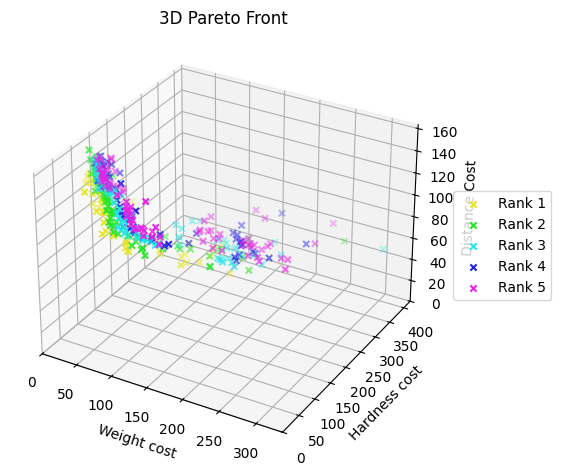

In [2]:
import weight
import hardness
import distance
import evolution_3d

m = 1000
weight_costs, hardness_costs, distance_costs = [], [], []
for i in range(m):
    if i < m/3:
        order = weight.generate_weightgreedy_random_order(shopping_list, alpha = 0.5)
    elif i < 2/3*m:
        order = hardness.generate_hardness_greedy_order(shopping_list, alpha=0.5)
    else:
        order = distance.generate_distancegreedy_random_order(J_product, alpha = 0.5)

    weight_cost = weight.compute_weight_cost(order, shopping_list)
    weight_costs.append(weight_cost)
    hardness_cost = hardness.compute_hardness_cost(order, shopping_list)
    hardness_costs.append(hardness_cost)
    distance_cost = distance.compute_timecost_from_middle_indices_order(order, J_product)
    distance_costs.append(distance_cost)
import matplotlib.pyplot as plt
final_ranking, ranks, crowding_distances = evolution_3d.pareto_rank_3_with_crowding(weight_costs, hardness_costs, distance_costs)
evolution_3d.plot_pareto_3(ranks, weight_costs, hardness_costs, distance_costs, xlabel="Weight cost", ylabel="Hardness cost", zlabel = "Distance Cost", max_legend_ranks=6, plot_high_ranks=False)


# 3D Evolution

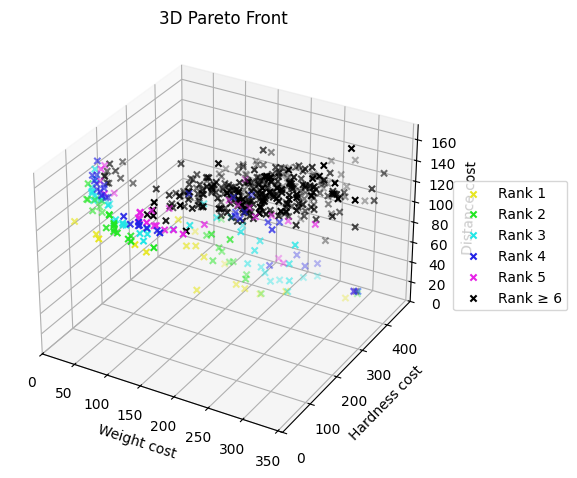

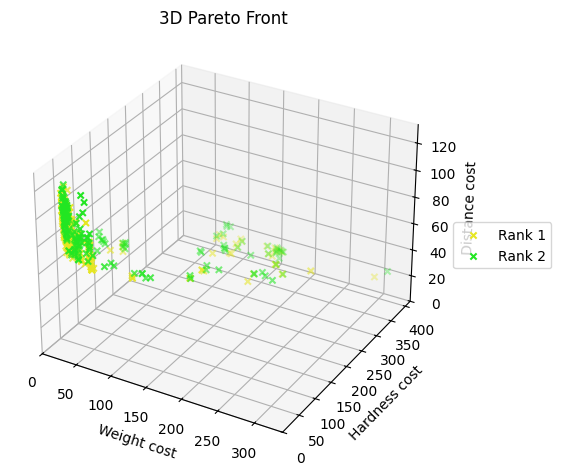

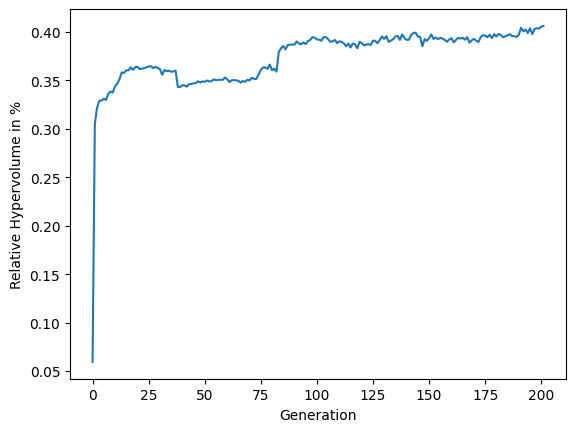

In [3]:
import evolution_3d
import hypervolume as hv

reference_point = (200, 400, 500)
population, pareto_ranks, ranking, weight_costs, hardness_costs, distance_costs, hypervolume_list, reference_point = evolution_3d.evolution_3d(
            shopping_list, J_product, patience=10, generation_size=100, population_size=500, reference_point=reference_point)
evolution_3d.plot_pareto_3(pareto_ranks, weight_costs, hardness_costs, distance_costs, xlabel="Weight cost", ylabel="Hardness cost", zlabel="Distance cost", max_legend_ranks=6, plot_high_ranks=True, reference_point=None, saving_path = "pareto_front_3d.jpg")
hv.plot_hypervolume(hypervolume_list, saving_path="hypervolume_3d.jpg")


ORDER COSTS: Distance = 52 (0.3) | Weight = 45 (0.14) | Hardness = 147 (0.39)
['Water', 'Orange Juice', 'Spezi', 'Beer', 'Frozen Burritos', 'Pizza', 'Sausage', 'Tuna', 'Salmon', 'Chicken Breast', 'Cheddar', 'Chocolate', 'Toiletpaper', 'Cracker', 'Flowers', 'Apple', 'Banana', 'Broccoli', 'Carrot', 'Soy Milk', 'Lasagna', 'Cashews', 'Almonds', 'Mozzarella', 'Tabasco', 'Croissant', 'Baguette']
Weights in order:                   [4, 3, 3, 5, 3, 3, 3, 3, 3, 3, 2, 2, 2, 1, 1, 1, 1, 2, 1, 2, 3, 1, 1, 2, 1, 1, 2]
Hardness in order:                  [5, 5, 5, 5, 4, 4, 4, 5, 3, 2, 3, 3, 1, 2, 1, 2, 1, 2, 3, 3, 4, 4, 4, 2, 5, 1, 2]
Distance between products:          [4, 1, 1, 1, 1, 1, 5, 2, 1, 1, 1, 7, 2, 1, 7, 1, 0, 1, 0, 2, 1, 2, 0, 2, 2, 1, 0, 4]
Mean path length between each step: 1.8571428571428572


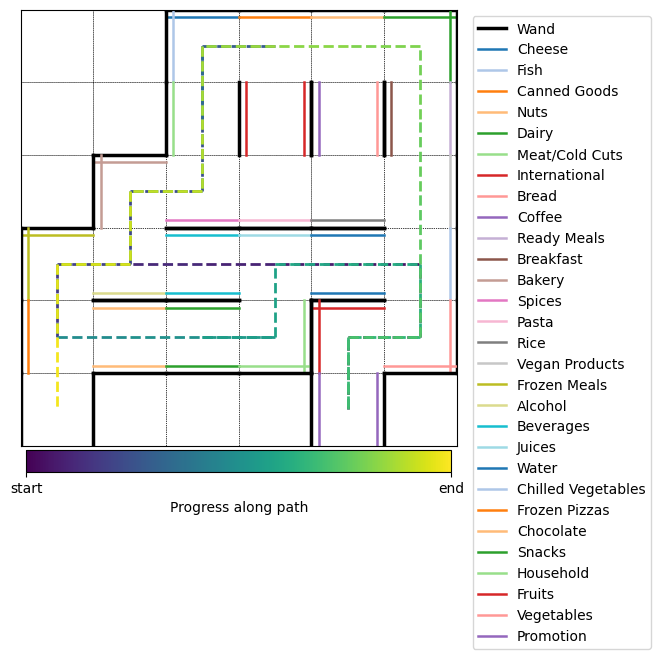

In [4]:
import order_functions
import decision_making as dm
import numpy as np

# Filter Pareto-Rank 1
population, pareto_ranks, ranking, weight_costs, hardness_costs, distance_costs = evolution_3d.filter_best_pareto_rank(population, pareto_ranks, ranking, weight_costs, hardness_costs, distance_costs)


# Normalize Costs
norm_distance_costs = dm.normalize_cost(distance_costs)
norm_weight_costs = dm.normalize_cost(weight_costs)
norm_hardness_costs = dm.normalize_cost(hardness_costs)

# Weighted sum
weights = [0.6, 0.3, 0.1] # Distance, Weight, Hardness
scores = dm.weighted_sum_for_list(cost_lists = [norm_distance_costs, norm_weight_costs, norm_hardness_costs], weights=weights)
ind = scores.index(min(scores))
#print(min(scores))

# Order & Costs
order = population[ind]
distance_cost, norm_distance_cost = distance_costs[ind], norm_distance_costs[ind]
weight_cost, norm_weight_cost = weight_costs[ind], norm_weight_costs[ind]
hardness_cost, norm_hardness_cost = hardness_costs[ind], norm_hardness_costs[ind]
print(f"ORDER COSTS: Distance = {distance_cost} ({round(norm_distance_cost,2)}) | Weight = {weight_cost} ({round(norm_weight_cost,2)}) | Hardness = {hardness_cost} ({round(norm_hardness_cost,2)})")

# Products
index_to_product = {v: k for k, v in shopping_list.product_indizes.items()}
products_in_order = [index_to_product[i] for i in order]
print(products_in_order)

# Weight and Hardness
# Mapping Name -> Produktobjekt
product_lookup = {p.name: p for p in shopping_list.products}

# Hardness und Weight in der gleichen Reihenfolge wie die Route
weights_in_order = [product_lookup[name].weight for name in products_in_order]
hardness_in_order = [product_lookup[name].hardness for name in products_in_order]

label_width = 35  # Breite der Labels für Ausrichtung
print(f"{'Weights in order:':<{label_width}} {weights_in_order}")
print(f"{'Hardness in order:':<{label_width}} {hardness_in_order}")

#Path
path = order_functions.get_path_from_middle_indices_order(order, P_product)
#print(path)

# Mean path length
path_length_between_each_step = [len(x)-1 for x in path]
print(f"{'Distance between products:':<{label_width}} {path_length_between_each_step}")
print(f"Mean path length between each step: {np.mean(path_length_between_each_step)}")

# Plot
saving_path = f"path_3d_d{distance_cost}_w{weight_cost}_h{hardness_cost}|d{weights[0]}_w{weights[1]}_h{weights[2]}.jpg"
grid.plot(path, saving_path=saving_path)